In [2]:
import yfinance as yf
import pandas as pd
import numpy as np

print("EquiLens data environment ready!")

EquiLens data environment ready!


In [3]:
stock=yf.Ticker("AAPL")
data=stock.history(period='1y')
data.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-09-09 00:00:00-04:00,236.127759,237.901207,232.501156,233.487518,66313900,0.0,0.0
2025-09-10 00:00:00-04:00,231.335457,231.564607,225.118417,225.955322,83440800,0.0,0.0
2025-09-11 00:00:00-04:00,226.045010,229.601863,225.815845,229.183411,50208600,0.0,0.0
2025-09-12 00:00:00-04:00,228.376401,233.646925,228.177140,233.208557,55824200,0.0,0.0
2025-09-15 00:00:00-04:00,236.127756,237.313379,234.165005,235.828857,42699500,0.0,0.0


In [4]:
print("Shape:",data.shape)
print("Columns:",data.columns.tolist())

Shape: (251, 7)
Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']


In [5]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 251 entries, 2025-09-09 00:00:00-04:00 to 2026-09-08 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          251 non-null    float64
 1   High          251 non-null    float64
 2   Low           251 non-null    float64
 3   Close         251 non-null    float64
 4   Volume        251 non-null    int64  
 5   Dividends     251 non-null    float64
 6   Stock Splits  251 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 15.7 KB


In [6]:
print("Start Date:",data.index.min())
print("End Date:",data.index.max())
print("trading days:",len(data))
print("missing values:",data.isna().sum().sum())

Start Date: 2025-09-09 00:00:00-04:00
End Date: 2026-09-08 00:00:00-04:00
trading days: 251
missing values: 0


In [7]:
data.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,251.000000,251.000000,251.000000,251.000000,2.510000e+02,251.000000,251.0
mean,277.736935,280.842341,275.023049,278.025082,4.949124e+07,0.004223,0.0
std,24.991318,25.531630,24.788850,25.290132,2.268670e+07,0.033258,0.0
min,226.045010,229.601863,225.118417,225.955322,1.791060e+07,0.000000,0.0
25%,258.093490,260.669801,255.569156,258.531708,3.828785e+07,0.000000,0.0
50%,271.600701,274.450243,269.167338,271.655243,4.501530e+07,0.000000,0.0
75%,297.888078,301.594893,295.245367,298.662415,5.251820e+07,0.000000,0.0
max,339.736982,344.273097,337.059318,339.786926,2.617755e+08,0.270000,0.0


In [8]:
data["Daily_Return"] = data["Close"].pct_change()

data[["Close", "Daily_Return"]].head(10)

,Close,Daily_Return
Date,,
2025-09-09 00:00:00-04:00,233.487518,NaN
2025-09-10 00:00:00-04:00,225.955322,-0.032260
2025-09-11 00:00:00-04:00,229.183411,0.014286
2025-09-12 00:00:00-04:00,233.208557,0.017563
2025-09-15 00:00:00-04:00,235.828857,0.011236
2025-09-16 00:00:00-04:00,237.273514,0.006126
2025-09-17 00:00:00-04:00,238.110443,0.003527
2025-09-18 00:00:00-04:00,237.004517,-0.004645
2025-09-19 00:00:00-04:00,244.596466,0.032033


In [9]:
data["Daily_Return"].describe()

count    250.000000
mean       0.001339
std        0.015814
min       -0.073539
25%       -0.006665
50%        0.001281
75%        0.009316
max        0.048407
Name: Daily_Return, dtype: float64

Matplotlib is building the font cache; this may take a moment.


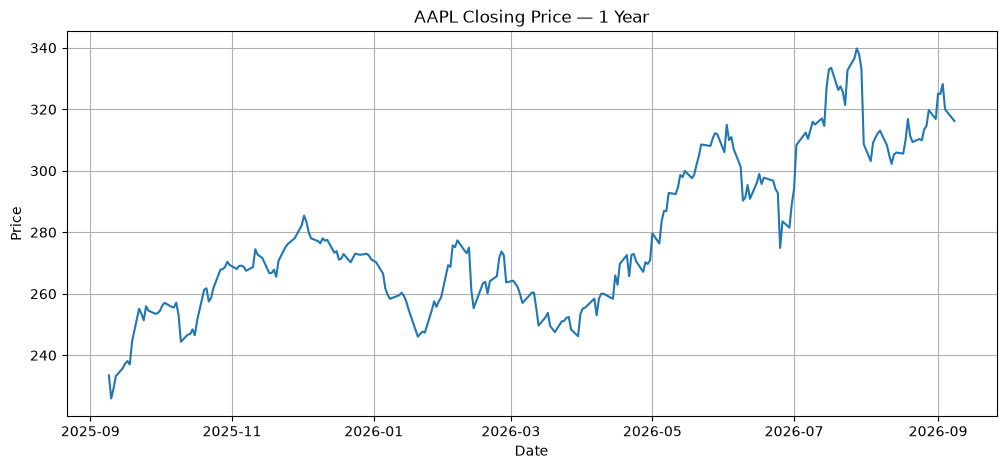

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(data.index, data["Close"])
plt.title("AAPL Closing Price — 1 Year")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

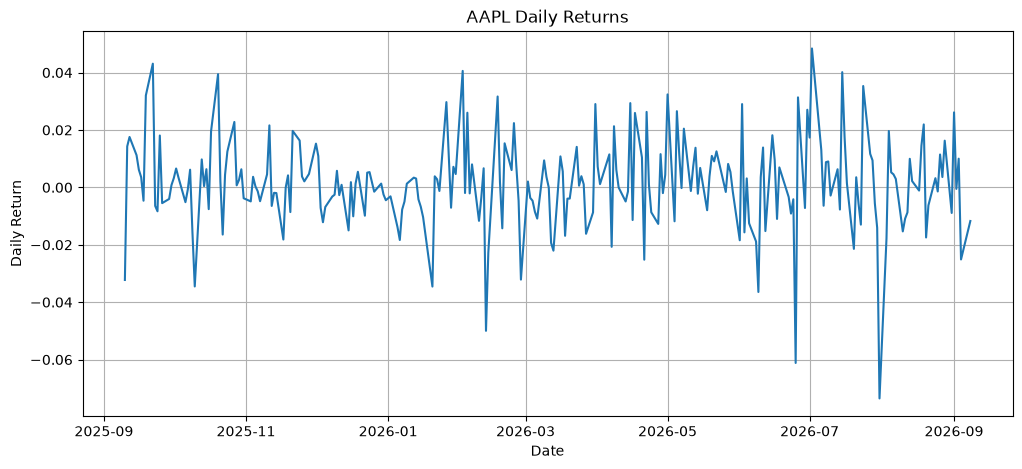

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(data.index, data["Daily_Return"])
plt.title("AAPL Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.grid(True)
plt.show()